In [10]:
# ------------------------------------------------------------
# 1. Carga de Datos y Librerías
# ------------------------------------------------------------

import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display as mostrar

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.4f}".format)

sns.set_style("whitegrid")

processed_dir = "../Data/processed"

print("Cargando datasets procesados...")

X_train = pd.read_csv(
    os.path.join(processed_dir, "X_train_reg.csv")
)

X_test = pd.read_csv(
    os.path.join(processed_dir, "X_test_reg.csv")
)

y_train = pd.read_csv(
    os.path.join(processed_dir, "y_train_reg.csv")
).squeeze()

y_test = pd.read_csv(
    os.path.join(processed_dir, "y_test_reg.csv")
).squeeze()

print(f"X_train: {X_train.shape}")
print(f"X_test : {X_test.shape}")

print(f"y_train: {y_train.shape}")
print(f"y_test : {y_test.shape}")


Cargando datasets procesados...
X_train: (2164, 32)
X_test : (542, 32)
y_train: (2164,)
y_test : (542,)


In [11]:
# ============================================================
# 15. Modelado y Extracción de Patrones
# ============================================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

gb_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

print("Entrenando Random Forest Regressor...")
rf_model.fit(X_train, y_train)

print("Entrenando Gradient Boosting Regressor...")
gb_model.fit(X_train, y_train)

print("Entrenamiento completado.")

Entrenando Random Forest Regressor...
Entrenando Gradient Boosting Regressor...
Entrenamiento completado.


In [12]:
# ============================================================
# 16. Evaluación de Modelos
# ============================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

y_pred_rf = rf_model.predict(X_test)
y_pred_gb = gb_model.predict(X_test)

def evaluar_modelo(nombre, y_real, y_pred):

    mae = mean_absolute_error(y_real, y_pred)

    mse = mean_squared_error(y_real, y_pred)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_real, y_pred)

    print("="*60)
    print(f"RESULTADOS - {nombre}")
    print("="*60)

    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")

    print()

evaluar_modelo(
    "RANDOM FOREST",
    y_test,
    y_pred_rf
)

evaluar_modelo(
    "GRADIENT BOOSTING",
    y_test,
    y_pred_gb
)


RESULTADOS - RANDOM FOREST
MAE  : 0.7729
MSE  : 1.2159
RMSE : 1.1027
R²   : 0.7531

RESULTADOS - GRADIENT BOOSTING
MAE  : 0.7834
MSE  : 1.2147
RMSE : 1.1021
R²   : 0.7534



In [13]:
# ============================================================
# 17. Modelo Base - Regresión Lineal
# ============================================================

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

lr_model = LinearRegression()

print("Entrenando Regresión Lineal...")

lr_model.fit(
    X_train_scaled,
    y_train
)

y_pred_lr = lr_model.predict(
    X_test_scaled
)

evaluar_modelo(
    "REGRESIÓN LINEAL",
    y_test,
    y_pred_lr
)

Entrenando Regresión Lineal...
RESULTADOS - REGRESIÓN LINEAL
MAE  : 1.0266
MSE  : 1.8115
RMSE : 1.3459
R²   : 0.6322



,Variable,Importancia
5,pl_rade,0.2995
3,pl_orbper,0.1534
4,pl_orbsmax,0.1221
16,sy_dist,0.1001
11,st_mass,0.0561
1,sy_pnum,0.0555
2,discoverymethod,0.0228
15,dec,0.0185
17,sy_vmag,0.0174
9,st_teff,0.0173


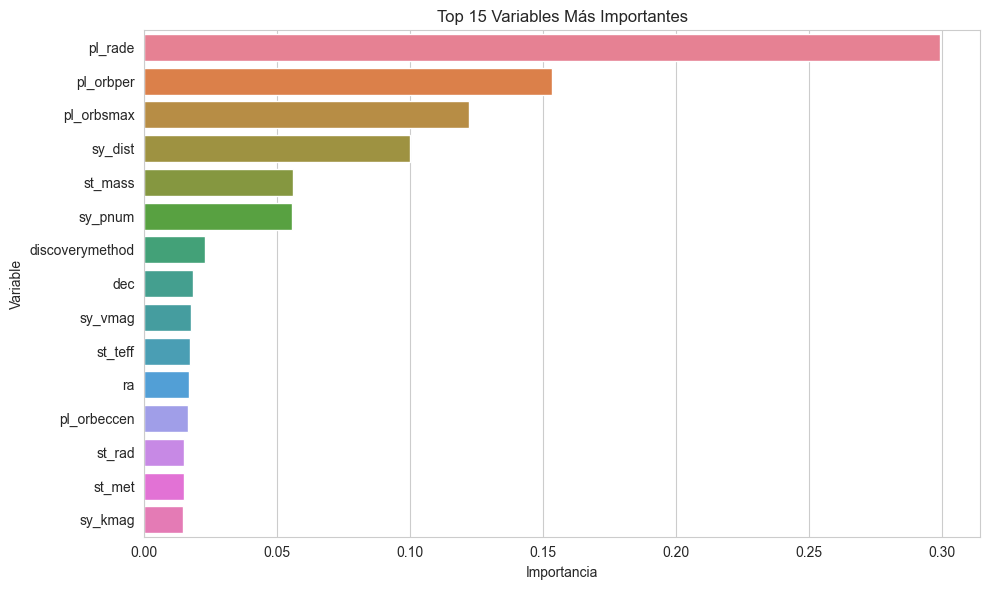

In [14]:
# ============================================================
# 18. Importancia de Variables
# ============================================================

importances = rf_model.feature_importances_

feat_imp = pd.DataFrame({
    "Variable": X_train.columns,
    "Importancia": importances
})

feat_imp = feat_imp.sort_values(
    "Importancia",
    ascending=False
).head(15)

mostrar(feat_imp)

plt.figure(figsize=(10,6))

sns.barplot(
    data=feat_imp,
    x="Importancia",
    y="Variable",
    hue="Variable",
    legend=False
)

plt.title(
    "Top 15 Variables Más Importantes"
)

plt.tight_layout()
plt.show()

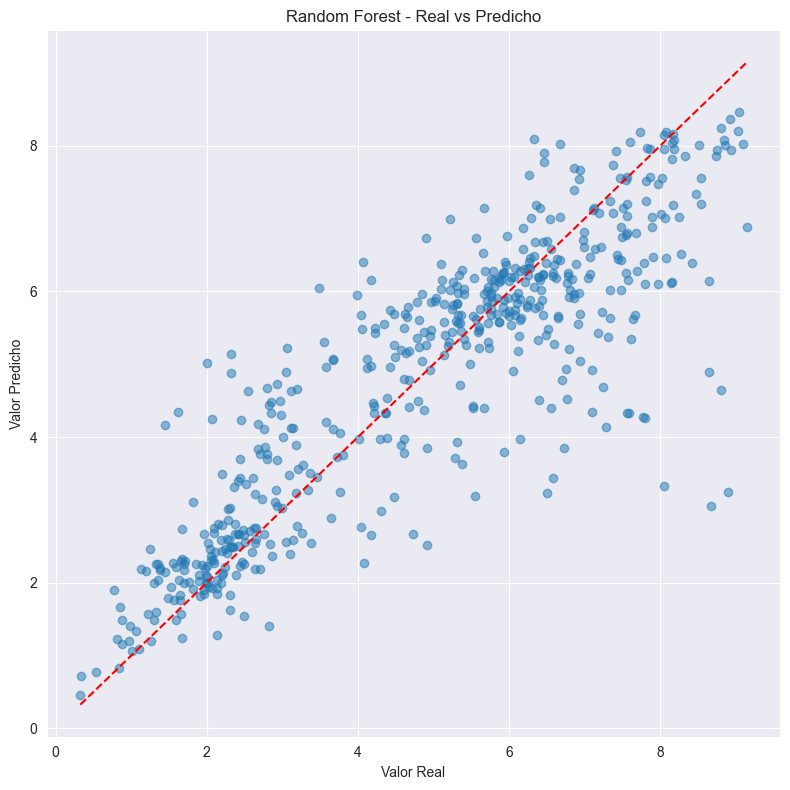

In [15]:
# ============================================================
# 19. Predicción vs Real
# ============================================================

plt.figure(figsize=(8,8))

plt.scatter(
    y_test,
    y_pred_rf,
    alpha=0.5
)

plt.xlabel("Valor Real")
plt.ylabel("Valor Predicho")

plt.title(
    "Random Forest - Real vs Predicho"
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.tight_layout()
plt.show()

,Modelo,R2,RMSE,MAE
0,Random Forest,0.7531,1.1027,0.7729
1,Gradient Boosting,0.7534,1.1021,0.7834
2,Regresión Lineal,0.6322,1.3459,1.0266


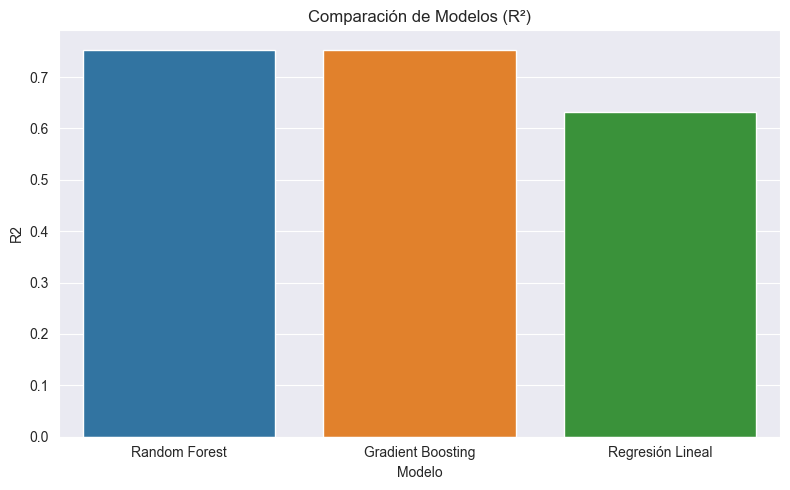

In [16]:
# ============================================================
# 20. Comparación de Modelos
# ============================================================

metricas = pd.DataFrame({

    "Modelo": [
        "Random Forest",
        "Gradient Boosting",
        "Regresión Lineal"
    ],

    "R2": [
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_gb),
        r2_score(y_test, y_pred_lr)
    ],

    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test, y_pred_gb)),
        np.sqrt(mean_squared_error(y_test, y_pred_lr))
    ],

    "MAE": [
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_gb),
        mean_absolute_error(y_test, y_pred_lr)
    ]
})

mostrar(metricas)

plt.figure(figsize=(8,5))

sns.barplot(
    data=metricas,
    x="Modelo",
    y="R2",
    hue="Modelo",
    legend=False
)

plt.title(
    "Comparación de Modelos (R²)"
)

plt.tight_layout()
plt.show()


In [17]:
# ============================================================
# 21. Conclusiones
# ============================================================

mejor_idx = metricas["R2"].idxmax()

mejor_modelo = metricas.loc[
    mejor_idx,
    "Modelo"
]

print("="*80)
print("CONCLUSIONES")
print("="*80)

print(f"Mejor modelo: {mejor_modelo}")

print("\nResumen de métricas:")
mostrar(metricas)

print("""
Interpretación:

- MAE indica el error absoluto promedio.
- RMSE penaliza más los errores grandes.
- R² indica qué porcentaje de la variabilidad
  de la masa planetaria logra explicar el modelo.

Mientras más alto sea R² y más bajos sean
MAE y RMSE, mejor será el modelo.
""")


CONCLUSIONES
Mejor modelo: Gradient Boosting

Resumen de métricas:


,Modelo,R2,RMSE,MAE
0,Random Forest,0.7531,1.1027,0.7729
1,Gradient Boosting,0.7534,1.1021,0.7834
2,Regresión Lineal,0.6322,1.3459,1.0266



Interpretación:

- MAE indica el error absoluto promedio.
- RMSE penaliza más los errores grandes.
- R² indica qué porcentaje de la variabilidad
  de la masa planetaria logra explicar el modelo.

Mientras más alto sea R² y más bajos sean
MAE y RMSE, mejor será el modelo.



In [18]:
# # ============================================================
# # 20. CONCLUSIONES E INTERPRETACIÓN DEL CONOCIMIENTO
# # ============================================================
#
# print("\n" + "="*80)
# print("CONCLUSIONES E INTERPRETACIÓN DEL CONOCIMIENTO OBTENIDO")
# print("="*80)
#
# diferencias = [
#     metricas['Accuracy Train'][i] - metricas['Accuracy Test'][i]
#     for i in range(len(modelos))
# ]
#
# conclusion_text = f"""
# 1. DESEMPEÑO GLOBAL:
#    - Mejor modelo según F1 Macro: {mejor_modelo_nombre}
#    - Accuracy en test: {metricas['Accuracy Test'][mejor_idx]:.2%}
#    - F1 Macro: {mejor_f1_macro:.4f}
#    - F1 Ponderado: {mejor_f1_ponderado:.4f}
#
#    El F1 Macro se utiliza como métrica principal porque da la misma importancia
#    a Transit, Radial Velocity, Microlensing y Others.
#
# 2. COMPARACIÓN DE ENFOQUES:
#    - Random Forest combina múltiples árboles independientes y prioriza estabilidad.
#    - Gradient Boosting construye árboles secuenciales que corrigen errores previos.
#    - Regresión Logística funciona como baseline lineal, simple e interpretable.
#
#    Si los árboles superan a la Regresión Logística, esto sugiere que existen
#    relaciones no lineales importantes entre las variables y el método de descubrimiento.
#
# 3. ANÁLISIS DE GENERALIZACIÓN:
#    - Diferencia Train-Test (RF): {diferencias[0]:.4f}
#    - Diferencia Train-Test (GB): {diferencias[1]:.4f}
#    - Diferencia Train-Test (Regresión Logística): {diferencias[2]:.4f}
#
#    Interpretación: {'Los tres modelos presentan una generalización aceptable' if max(diferencias) < 0.15 else 'Al menos un modelo presenta signos de overfitting moderado'}.
#
# 4. VARIABLES MÁS PREDICTIVAS:
#    Las propiedades orbitales, físicas y estelares aportan información relevante
#    para distinguir los métodos de descubrimiento.
#
# 5. CONCLUSIÓN FINAL:
#    El ETL sin data leakage, el balanceo con SMOTEENN y la comparación contra
#    un baseline lineal permiten evaluar de manera más sólida qué modelo captura
#    mejor los patrones presentes en los datos.
#
# 6. MEJORAS FUTURAS:
#    - Aplicar GridSearchCV o RandomizedSearchCV para seleccionar hiperparámetros.
#    - Utilizar validación cruzada estratificada.
#    - Incorporar SHAP para interpretar las predicciones.
# """
#
# print(conclusion_text)
# print("\n" + "="*80)
# print("MODELADO Y ANÁLISIS COMPLETADOS")
# print("="*80)
#
